In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
# final model comparison
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Weighted XGBoost",
        "ANN"
    ],
    "Precision": [
        0.074,
        0.174,
        0.932,
        0.337,
        0.870
    ],
    "Recall": [
        0.686,
        0.761,
        0.509,
        0.827,
        0.440
    ],
    "F1_Score": [
        0.134,
        0.283,
        0.658,
        0.479,
        0.580
    ],
    "ROC_AUC": [
        0.754,
        0.889,
        0.952,
        0.957,
        0.914
    ]
})

model_comparison

,Model,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.074,0.686,0.134,0.754
1,Random Forest,0.174,0.761,0.283,0.889
2,XGBoost,0.932,0.509,0.658,0.952
3,Weighted XGBoost,0.337,0.827,0.479,0.957
4,ANN,0.870,0.440,0.580,0.914


In [4]:
# sorting by ROC AUC
model_comparison.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,Precision,Recall,F1_Score,ROC_AUC
3,Weighted XGBoost,0.337,0.827,0.479,0.957
2,XGBoost,0.932,0.509,0.658,0.952
4,ANN,0.870,0.440,0.580,0.914
1,Random Forest,0.174,0.761,0.283,0.889
0,Logistic Regression,0.074,0.686,0.134,0.754


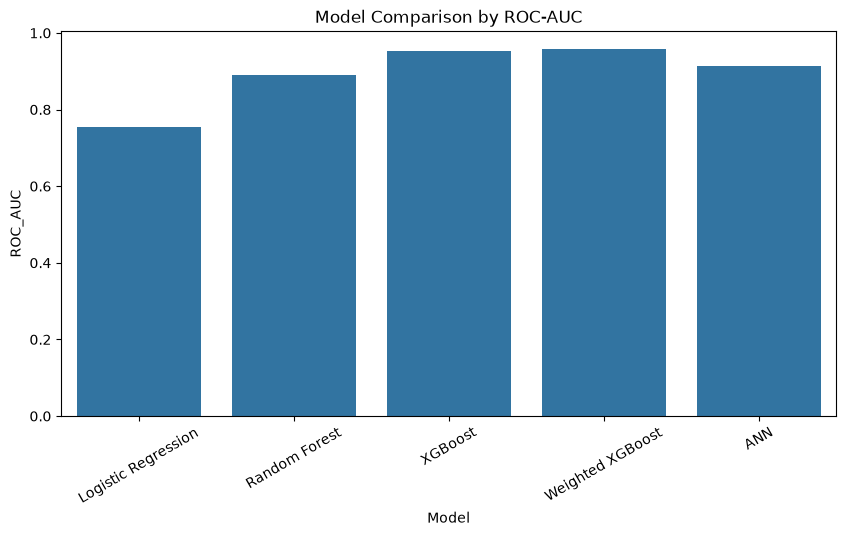

In [5]:
# Visualize ROC-AUC Comparison
plt.figure(figsize=(10,5))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="ROC_AUC"
)

plt.title("Model Comparison by ROC-AUC")
plt.xticks(rotation=30)
plt.show()

<Figure size 1000x500 with 0 Axes>

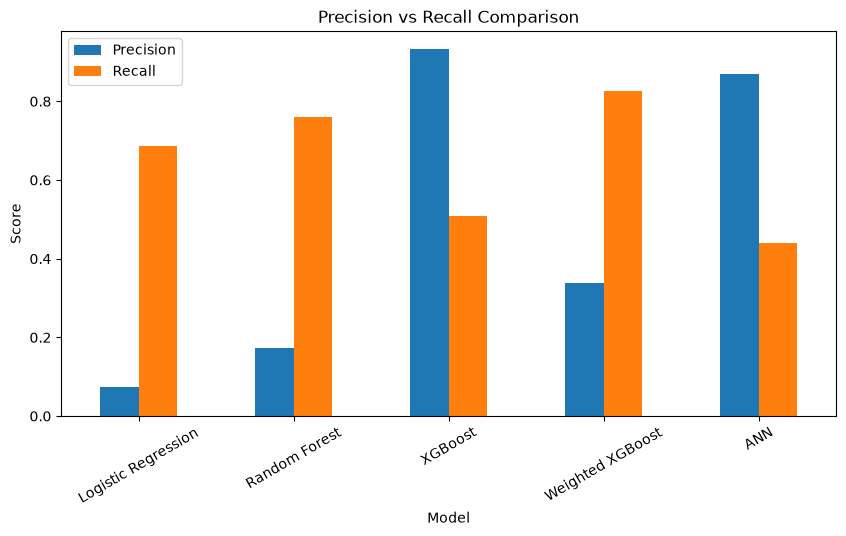

In [6]:
# Visualize Precision vs Recall
plt.figure(figsize=(10,5))

model_comparison.set_index("Model")[["Precision", "Recall"]].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Precision vs Recall Comparison")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.show()

# Final Model Selection

Weighted XGBoost was selected as the final production model.

## Reason

Although standard XGBoost achieved very high precision, it missed a large portion of fraudulent transactions.

Weighted XGBoost achieved the best overall fraud detection capability with:

- ROC-AUC: 0.957
- Recall: 82.7%
- Precision: 33.7%

For fraud detection, recall is extremely important because missing fraudulent transactions can cause direct financial losses.

Therefore, Weighted XGBoost is the best model for this project.

# Threshold Optimization

The default threshold of 0.50 gave high recall but moderate precision.

After testing multiple thresholds, threshold 0.70 provided a better balance:

- Precision: 59.5%
- Recall: 72.2%
- F1 Score: 65.2%

This threshold is recommended for business deployment because it reduces false alarms while still detecting most fraud cases.

In [7]:
model_comparison.to_csv(
    "../outputs/final_model_comparison.csv",
    index=False
)

print("Final model comparison saved successfully")

Final model comparison saved successfully


In [8]:
business_summary = """
Final Model Selected: Weighted XGBoost

Reason:
Weighted XGBoost achieved the highest ROC-AUC score of 0.957 and strong fraud recall of 82.7%.

Business Recommendation:
For production use, a threshold of 0.70 is recommended because it provides a strong balance between precision and recall.

Key Business Impact:
- Improved fraud detection capability
- Reduced financial risk
- Better transaction monitoring
- Explainable fraud intelligence through SHAP
"""

with open("../outputs/final_business_summary.txt", "w") as file:
    file.write(business_summary)

print("Business summary saved successfully")

Business summary saved successfully
